**Lab10**


In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [201]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cancer_coded.csv')

df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0


In [202]:
df.isnull().sum()

,0
Sample code number,0
Clump Thickness,0
Uniformity of Cell Size,0
Uniformity of Cell Shape,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bare Nuclei,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0


In [203]:
print(df.columns)

Index(['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size',
       'Uniformity of Cell Shape', 'Marginal Adhesion',
       'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
       'Normal Nucleoli', 'Mitoses', 'Class'],
      dtype='object')


In [204]:
clean_df = df.drop(['Sample code number'], axis=1)

clean_df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


In [205]:
validation_data = pd.DataFrame([[5, 9, 9, 3, 7, 3, 8, 9, 2, -1],[3, 2, 1, 1, 2, 3, 1, 1, 1, -1]], columns = clean_df.columns)

validation_data

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,9,9,3,7,3,8,9,2,-1
1,3,2,1,1,2,3,1,1,1,-1


In [206]:
clean_df = pd.concat([clean_df, validation_data], ignore_index=True)
clean_df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


In [207]:
from sklearn.preprocessing import StandardScaler

In [208]:
scaler = StandardScaler()

X = df.drop('Class', axis = 1)

scaler = StandardScaler()
scaler.fit(X)


StandardScaler()

In [209]:
scaled_features = scaler.transform(X)
scaled_features

array([[-0.12366418,  0.19790469, -0.70221201, ..., -0.18182716,
        -0.61292736, -0.34839971],
       [-0.11895594,  0.19790469,  0.27725185, ..., -0.18182716,
        -0.28510482, -0.34839971],
       [-0.09883306, -0.51164337, -0.70221201, ..., -0.18182716,
        -0.61292736, -0.34839971],
       ...,
       [-0.30297227,  0.19790469,  2.23617957, ...,  1.86073779,
         2.33747554,  0.22916583],
       [-0.2890233 , -0.15686934,  1.58320366, ...,  2.67776377,
         1.02618536, -0.34839971],
       [-0.2890233 , -0.15686934,  1.58320366, ...,  2.67776377,
         0.37054027, -0.34839971]])

In [210]:
scale_column = df.columns.drop('Class')
scale_df = df[scale_column]
scaled_df = scaler.fit_transform(scale_df)
df_scaled_df = pd.DataFrame(scaled_df, columns = scale_column)
df_scaled_df['Class'] = df['Class']
df_scaled_df

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,-0.123664,0.197905,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.181827,-0.612927,-0.348400,0
1,-0.118956,0.197905,0.277252,0.262783,0.758032,1.695166,1.772867,-0.181827,-0.285105,-0.348400,0
2,-0.098833,-0.511643,-0.702212,-0.741774,-0.639366,-0.555608,-0.424217,-0.181827,-0.612927,-0.348400,0
3,-0.097459,0.552679,1.583204,1.602192,-0.639366,-0.105454,0.125054,-0.181827,1.354008,-0.348400,0
4,-0.096256,-0.156869,-0.702212,-0.741774,0.059333,-0.555608,-0.698853,-0.181827,-0.612927,-0.348400,0
...,...,...,...,...,...,...,...,...,...,...,...
678,-0.483732,-0.511643,-0.702212,-0.741774,-0.639366,-0.105454,-0.424217,-0.998853,-0.612927,-0.348400,0
679,-0.378838,-0.866417,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,-0.348400,0
680,-0.302972,0.197905,2.236180,2.271896,0.059333,1.695166,-0.149582,1.860738,2.337476,0.229166,1
681,-0.289023,-0.156869,1.583204,0.932487,0.408682,-0.105454,0.125054,2.677764,1.026185,-0.348400,1


In [211]:
df_feat = pd.DataFrame(scaled_features, columns = df.columns[:-1])
df_feat.tail()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
678,-0.483732,-0.511643,-0.702212,-0.741774,-0.639366,-0.105454,-0.424217,-0.998853,-0.612927,-0.348400
679,-0.378838,-0.866417,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,-0.348400
680,-0.302972,0.197905,2.236180,2.271896,0.059333,1.695166,-0.149582,1.860738,2.337476,0.229166
681,-0.289023,-0.156869,1.583204,0.932487,0.408682,-0.105454,0.125054,2.677764,1.026185,-0.348400
682,-0.289023,-0.156869,1.583204,1.602192,0.758032,0.344701,0.399689,2.677764,0.370540,-0.348400


In [212]:
clean_df_for_training = clean_df.iloc[:-len(validation_data)]
clean_df_for_training.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0


In [213]:
#df_scaled_df
training_data = df_scaled_df.drop(df_scaled_df.index[-2:])
training_data

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,-0.123664,0.197905,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.181827,-0.612927,-0.348400,0
1,-0.118956,0.197905,0.277252,0.262783,0.758032,1.695166,1.772867,-0.181827,-0.285105,-0.348400,0
2,-0.098833,-0.511643,-0.702212,-0.741774,-0.639366,-0.555608,-0.424217,-0.181827,-0.612927,-0.348400,0
3,-0.097459,0.552679,1.583204,1.602192,-0.639366,-0.105454,0.125054,-0.181827,1.354008,-0.348400,0
4,-0.096256,-0.156869,-0.702212,-0.741774,0.059333,-0.555608,-0.698853,-0.181827,-0.612927,-0.348400,0
...,...,...,...,...,...,...,...,...,...,...,...
676,-0.584791,-0.511643,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,-0.348400,0
677,-0.505467,-0.511643,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.590340,-0.612927,0.229166,0
678,-0.483732,-0.511643,-0.702212,-0.741774,-0.639366,-0.105454,-0.424217,-0.998853,-0.612927,-0.348400,0
679,-0.378838,-0.866417,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,-0.348400,0


In [214]:
from sklearn.model_selection import train_test_split


In [215]:
X = df_scaled_df.drop('Class', axis = 1)
y = df_scaled_df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101)
X_test

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
660,0.465354,-1.221191,-0.702212,-0.406921,-0.639366,-0.555608,-0.698853,-0.590340,-0.612927,-0.348400
597,-0.409377,1.262227,2.236180,2.271896,2.504778,1.245011,1.772867,2.677764,2.337476,4.849690
494,0.356023,-0.866417,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,-0.348400
139,0.172952,1.617001,0.603740,0.597635,0.408682,0.344701,0.399689,0.226686,0.042718,0.806731
399,0.261578,1.262227,0.603740,0.932487,-0.290016,-0.105454,1.772867,1.043712,1.026185,-0.348400
...,...,...,...,...,...,...,...,...,...,...
627,0.351010,-1.221191,-0.702212,-0.741774,-0.639366,-0.555608,-0.698853,-0.998853,-0.612927,-0.348400
664,0.472599,1.971775,2.236180,2.271896,2.504778,0.794856,1.772867,2.677764,2.337476,3.116993
80,0.108447,0.197905,-0.375724,-0.741774,-0.639366,-0.555608,-0.698853,-0.181827,-0.612927,-0.348400
98,0.145010,1.971775,-0.049236,0.597635,-0.639366,3.045631,0.399689,-0.181827,2.337476,0.229166


In [216]:
# Import

from sklearn.neighbors import KNeighborsClassifier

In [217]:
# Instance of KNN, start with K of 1

model = KNeighborsClassifier(n_neighbors = 1)

In [218]:
# Fit

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [219]:
# Predictions on X_test

predictions = model.predict(X_test)
predictions

array([0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0])

In [220]:
# Imports

from sklearn.metrics import confusion_matrix, classification_report

<Axes: >

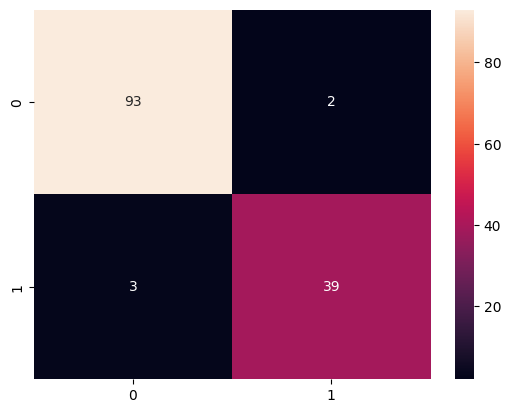

In [221]:
# Confusion Matrix via Heat Map

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot = True, fmt = 'g')

In [222]:
# Classification Report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97        95
           1       0.95      0.93      0.94        42

    accuracy                           0.96       137
   macro avg       0.96      0.95      0.96       137
weighted avg       0.96      0.96      0.96       137



In [223]:
#1.What is the accuracy of the model based on classification report? add code and answer

print("Based on the classification report provided in the last line of the code, the accuracy of the model is 0.97.")


Based on the classification report provided in the last line of the code, the accuracy of the model is 0.97.


In [224]:
#2. What is the prediction on the 1st validation data? (0 or 1)?
first_validation_data = df_scaled_df.iloc[-2:-1].drop('Class', axis=1)

prediction_first_validation = model.predict(first_validation_data)

print(f"The prediction on the 1st validation data is: {prediction_first_validation[0]}")

The prediction on the 1st validation data is: 1


In [225]:
#3. What is the prediction on the 2nd validation data? (0 or 1?

second_validation_data = df_scaled_df.iloc[-1:].drop('Class', axis=1)
prediction_second_validation = model.predict(second_validation_data)
print(f"The prediction on the 2nd validation data is: {prediction_second_validation[0]}")

The prediction on the 2nd validation data is: 1


In [226]:
#4 to 5. Give at least two variables that can highly predict the 'Outcome Predicton' based on Logistics Graphs
from sklearn.linear_model import LogisticRegression
import pandas as pd

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

coefficients = pd.DataFrame(log_model.coef_[0], index=X.columns, columns=['Coefficient'])
sorted_coefficients = coefficients.abs().sort_values(by='Coefficient', ascending=False)

print("Top predictor variables based on coefficient magnitude:")
print(sorted_coefficients.head(2))



Top predictor variables based on coefficient magnitude:
                 Coefficient
Clump Thickness     1.210775
Bare Nuclei         1.086768
